![iSA logo](../iSA_logo.png)
### Materiały do zajęć Statystyka
#### Kurs Junior Data Scientist

**Wojciech Artichowicz**

### Praca z rozkładami prawdopodobieństwa w scipy

 * Rozkłady prawdopodobieństwa są dostępne w module [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html)
 * Rozkłady prawdopodbieństwa można wykorzystywać jako uogólnione obiekty lub jako obiekty z określonymi parametrami (frozen)
 * Domyślnie rozkłady są w formie unormowanej

### Użycie rozkładu zdefiniowanego w bibliotece scipy.stats

**Ładowanie wymaganych bibliotek**

In [1]:
from scipy import stats as st # import podstawowej biblioteki z obiektami rozkładów prawdopodobieństwa
import numpy as np # wymagane do manipulacji tablicami numpy
import matplotlib.pyplot as plt #biblioteki wymagane do wykresu
%matplotlib inline

**Definowanie parametrów i tworzenie instancji rozkładu typu frozen**

"frozen" oznacza, że zostały zdefiniowane wartości parametrów

In [2]:
mu = 3
s = 1
rozkladNormalny = st.norm(mu,s)

**Używanie gęstości rozkładu i dystrybuanty**

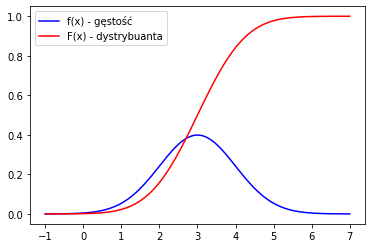

In [3]:
xn = np.linspace(mu-4*s,mu+4*s,1000) # wektor wartości x
fn = rozkladNormalny.pdf(xn) # wektor wartości gęstości rozkładu prawdopodobieństwa
Fn = rozkladNormalny.cdf(xn) # numeryczne obliczenie wartości dystrybuanty
                             
plt.plot(xn,fn,"blue",xn,Fn,"red")
plt.legend(["f(x) - gęstość","F(x) - dystrybuanta"])
pass

**Obliczenie prawdopodobieństwa, że zmienna losowa (o wyżej zdefiniowanym rozkładzie) przyjmie wartość z przedziału [a,b]=[4,5]**

$$P(a<X<b) = F(b)-F(a)$$

In [4]:
a = 4
b = 5
P = rozkladNormalny.cdf(b) - rozkladNormalny.cdf(a)
P

0.13590512198327787

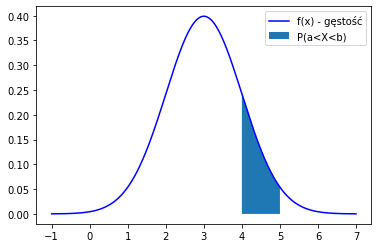

In [5]:
plt.plot(xn,fn,"blue")
t = np.linspace(a,b,100)
plt.fill_between(t,0,rozkladNormalny.pdf(t))
plt.legend(["f(x) - gęstość", "P(a<X<b)"])
pass

**Obliczanie kwantyla wyżej zdefiniowanego rozkładu**

1.7184484344553996


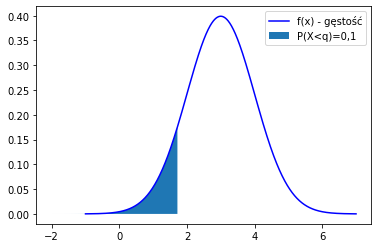

In [6]:
p = 0.1
q = rozkladNormalny.ppf(p)
print(q)

plt.plot(xn,fn,"blue")

t = np.linspace(mu-5*s,q,100)
plt.fill_between(t,0,rozkladNormalny.pdf(t))
plt.legend(["f(x) - gęstość", "P(X<q)=0,1"])
pass

### Tworzenie własnego rozkładu ciągłego

Podstawowym obiektem, na bazie którego tworzy się rozkłady pochodne jest [klasa rv_continuous](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_continuous.html#scipy.stats.rv_continuous). Wykorzystując mechanizm dziedziczenia możliwe jest definiowanie własnych rozkładów. 

**Uwaga** Tworząc nowy rozkład należy samodzielnie zapewnić spełnienie założeń teorii prawdopodobieństwa np.: $lim_{x \to \infty}F(x)=1$

**Uwaga** Jeśli nie zostaną przeciążone metody prywatne _logpdf, _cdf, _logcdf, _ppf, _rvs, _isf, _sf, _logsf, wówczas będą one obliczane numerycznie na podstawie metody _pdf albo _cdf. Metoda prywatna _pdf albo _cdf zawsze musi zostać zdefiniowana przez użytkownika.

**Tworzenie klasy reprezentującej dowolny rozkład (bezparametrowy)**

Dany jest rozkład prawdopodobieństwa o gęstości 

$$f(x)=\frac{2}{\pi(e^x+e^{-x})}$$

Utworzyć klasę reprezentującą ten rozkład.

**Ładowanie wymaganych bibliotek**

In [7]:
from scipy import stats as st # import podstawowej biblioteki z obiektami rozkładów prawdopodobieństwa
import numpy as np # wymagane do manipulacji tablicami numpy
import matplotlib.pyplot as plt #biblioteki wymagane do wykresu
%matplotlib inline

In [8]:
class rozklad1(st.rv_continuous): # dziedziczenie po klasie rv_continuous
    "własny rozkład o gęstości f(x)"
    def _pdf(self, x:float)->float: # przeciążenie funkcji _pdf (gęstość prawdopodobieństwa)
        return 2./(np.pi*(np.exp(x)+np.exp(-x)))
    
    #def _cdf(self, x:float)->float: # przeciążenie funkcji _cdf (dystrybuanta) 
    #    return (2./np.pi)*np.arctan(np.exp(x))    

C:\Users\miser\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: RuntimeWarning: overflow encountered in exp
  after removing the cwd from sys.path.


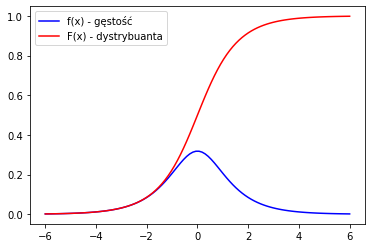

In [9]:
r1 = rozklad1() # utworzenie instancji obiektu rozkładu

x1 = np.linspace(-6,6,100) # wektor wartości x
f1 = r1.pdf(x1) # wektor wartości gęstości rozkładu prawdopodobieństwa
F1 = r1.cdf(x1) # numeryczne obliczenie wartości dystrybuanty, po odkomentowaniu metody
                # _cdf dystrubianta nie będzie obliczana numerycznie a na podstawie wzoru
plt.plot(x1,f1,"blue",x1,F1,"red")
plt.legend(["f(x) - gęstość","F(x) - dystrybuanta"])
pass

#### Tworzenie klasy reprezentującej ciągły rozkład prawdopodobieństwa z parametrami

Utworzyć  klasę reprezentująca [rozkład Cauchy](https://en.wikipedia.org/wiki/Cauchy_distribution) z parametrami: położenia $x_0$ oraz skali $\gamma$.

$$f(x)=\frac{1}{\pi \gamma \left[ 1 + \left(\frac{x-x_0}{\gamma}\right)^2 \right]}$$

$$F(x) = \frac{1}{\pi} \arctan \left(\frac{x-x_0}{\gamma}\right) + \frac{1}{2}$$

**Uwaga** Jest to przykład uproszczony nie dający pełnej funkcjonalności obiektów rozkładów ze scipy.stats: instancja tego obiektu może być tylko typu *frozen*. Pełną funkcjonalnośc można osiągnąć dzięki zastosowaniu słownika argumentów **kwargs

In [10]:
class rozklad2(st.rv_continuous): # dziedziczenie po klasie rv_continuous
    "kolejny własny rozkład o gęstości f(x)"
    
    def __init__(self,x0_a:float,gamma_a:float): 
        super().__init__()
        self.loc = x0_a            
        self.scale = gamma_a

    def _pdf(self, x:float)->float: # przeciążenie funkcji _pdf (gęstość prawdopodobieństwa)
        return 1./(np.pi*self.scale*(1.+((x-self.loc)/self.scale)**2.))
    
    def _cdf(self, x:float)->float: # przeciążenie funkcji _cdf (dystrybuanta) 
        return (1./np.pi)*np.arctan((x-self.loc)/self.scale)+0.5  

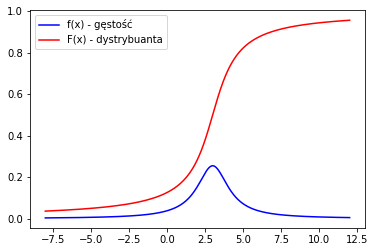

In [11]:
r2 = rozklad2(x0_a = 3, gamma_a = 1.25) # utworzenie instancji obiektu rozkładu

x2 = np.linspace(-8,12,1000) # wektor wartości x
f2 = r2.pdf(x2) # wektor wartości gęstości rozkładu prawdopodobieństwa
F2 = r2.cdf(x2) # obliczenie wartości dystrybuanty
plt.plot(x2,f2,"blue",x2,F2,"red")
plt.legend(["f(x) - gęstość","F(x) - dystrybuanta"])
pass